<a href="https://colab.research.google.com/github/KULDEEPSONI-source/DEEPLEARNING/blob/main/earlystoppingbeforeoverfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [13]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

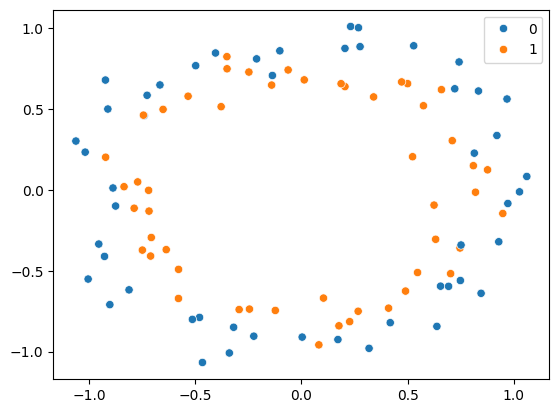

In [14]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [16]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

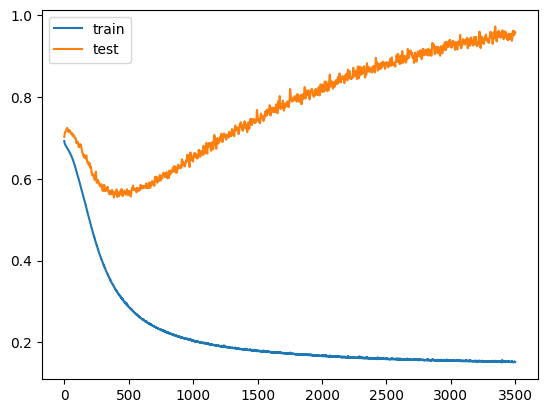

In [19]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

This code visualizes the decision boundaries of a trained classifier. Let me break it down properly:

## What Each Parameter Does

**`X_test`**
- The input features used to create the plot
- Typically 2D data (two features) since decision regions are visualized in 2D space
- If your data has more than 2 features, this won't work directly — you'd need dimensionality reduction (PCA) or select only 2 features

**`y_test.ravel()`**
- The target labels, flattened to a 1D array
- `.ravel()` converts shape `(n, 1)` or `(n,)` to a flat `(n,)` array — required by `mlxtend`'s API
- Must be integer class labels (0, 1, 2, ...) not one-hot encoded

**`clf = model`**
- The trained classifier whose decision boundaries you want to visualize
- Must have a `.predict()` method
- Works with: scikit-learn estimators, Keras models (with wrapper), XGBoost, etc.

**`legend=2`**
- Controls legend placement/behavior in `mlxtend`
- `2` typically means: show legend with class labels in a specific location (varies by version)

## What This Function Actually Does

`plot_decision_regions` from `mlxtend.plotting`:
1. Creates a mesh grid covering the range of your 2D feature space
2. Predicts the class for every point on that grid using `clf.predict()`
3. Colors the regions according to predicted class
4. Overlays your actual data points (`X_test`, `y_test`) on top
5. Shows which areas the model assigns to each class

## Critical Requirements

| Requirement | Why It Matters |
|-------------|--------------|
| Exactly **2 features** | Decision regions are 2D surfaces; 3+ features need projection |
| Classifier must implement `.predict()` | The function needs to query predictions across the grid |
| Labels must be integers | `mlxtend` expects integer class indices, not strings or one-hot |
| Small to moderate dataset | Large grids slow down; function samples if too many points |

## Common Issues

**"ValueError: X has more than 2 features"**
- Your data has >2 dimensions. Fix: select 2 features `X_test[:, [0, 2]]` or use PCA first

**Keras model doesn't work directly**
- Keras models aren't scikit-learn compatible by default. Wrap them:

```python
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Or for modern TF (2.6+), use scikeras:
from scikeras.wrappers import KerasClassifier

wrapped_model = KerasClassifier(model=your_keras_model, epochs=0)  # already trained
plot_decision_regions(X_test, y_test.ravel(), clf=wrapped_model, legend=2)
```

## Complete Working Example

```python
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

# Assuming X_test has exactly 2 features and model is trained
plt.figure(figsize=(10, 8))
plot_decision_regions(X_test, y_test.ravel(), clf=model, legend=2)

plt.title('Decision Regions - Test Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
```

## What the Plot Shows You

| Visual Element | Interpretation |
|----------------|----------------|
| Colored background regions | Where the model predicts each class |
| Data point markers | Actual test samples overlaid |
| Misclassified points | Points sitting in a differently-colored region than their marker color |
| Boundary sharpness | How confidently the model separates classes |

## Important Note

Using `X_test` (test data) for visualization is fine — you're not retraining or tuning. But if you use this to adjust your model, you're leaking test information. For hyperparameter decisions, use validation data instead.

Is your model Keras-based? If so, you'll need the wrapper I mentioned above, or you can manually plot decision regions by predicting on a mesh grid yourself.

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


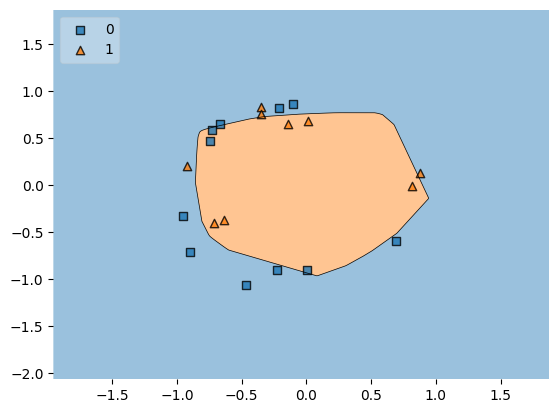

In [20]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

# Early Stopping

In [21]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

Here's a proper breakdown of every parameter in the `EarlyStopping` callback:

## What `EarlyStopping` Does

Stops training when a monitored metric stops improving, preventing unnecessary epochs and reducing overfitting.

---

## Parameter-by-Parameter Explanation

### `monitor="val_loss"`
- **What metric to watch**
- `"val_loss"`: validation loss (requires `validation_data` in `model.fit()`)
- Alternatives: `"val_accuracy"`, `"loss"`, `"accuracy"`, `"val_auc"`, etc.
- **Best practice**: Use `"val_loss"` for generalization; `"val_accuracy"` can be noisy

### `min_delta=0.00001`
- **Minimum change to qualify as an improvement**
- Only changes larger than this count as "better"
- `0.00001` means the metric must improve by at least 0.001% to reset patience
- **Purpose**: Ignores tiny fluctuations that don't represent real learning
- **Trade-off**: Too small = waits forever for meaningless gains; too large = stops prematurely

### `patience=20`
- **How many epochs to wait before stopping**
- If `val_loss` doesn't improve by `min_delta` for 20 consecutive epochs, training halts
- **Purpose**: Allows for temporary plateaus — models often have noisy valleys before finding better minima
- **With your 3500 epochs**: This is your safety net; training could stop at epoch 500 instead of running all 3500

### `verbose=1`
- **How much to print when stopping triggers**
- `0`: Silent
- `1`: Prints a message like *"Epoch 523: early stopping"* when it stops
- `2`: More detailed logging (epoch-by-epoch status)

### `mode="auto"`
- **How to interpret "improvement"**
- `"auto"`: Infers from metric name — decreases for `"loss"`, increases for `"accuracy"`
- `"min"`: Lower is better (for loss, error metrics)
- `"max"`: Higher is better (for accuracy, AUC, F1)
- **Risk**: `"auto"` usually works, but explicit `"min"`/`"max"` is safer for custom metrics

### `baseline=None`
- **Threshold that must be exceeded before patience counter starts**
- `None`: No threshold; patience starts counting from epoch 1
- If set (e.g., `baseline=0.5`), the model must first beat this value, then patience applies
- **Use case**: Skip early epochs where performance is garbage; only start watching after reaching a reasonable level

### `restore_best_weights=False`
- **Whether to revert to the best weights after stopping**
- `False`: Model keeps weights from the last epoch (when stopped)
- `True`: Rolls back to the weights from the epoch with the best `monitor` value
- **Critical**: `False` means you might end with worse weights than the best point during training. `True` is almost always what you want.

---

## How These Parameters Work Together

```
Epoch 100: val_loss = 0.4500  ← best so far
Epoch 101: val_loss = 0.4499  ← improved by 0.0001 (> min_delta), patience resets
Epoch 102: val_loss = 0.44985 ← improved by 0.00005 (> min_delta), patience resets
...
Epoch 150: val_loss = 0.44980 ← best so far
Epoch 151: val_loss = 0.44981 ← worse, patience = 1
Epoch 152: val_loss = 0.44982 ← worse, patience = 2
...
Epoch 170: val_loss = 0.45000 ← worse, patience = 20 → STOP
```

---

## Recommended Fix for Your Setup

```python
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,           # Slightly larger — 1e-5 is very strict
    patience=20,
    verbose=1,
    mode="min",                 # Explicit is safer than "auto"
    baseline=None,
    restore_best_weights=True   # ← Almost always want this
)
```

Then use it:

```python
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3500,
    callbacks=[callback],
    verbose=0
)
```

---

## With vs Without `restore_best_weights`

| Setting | Final Weights | When to Use |
|---------|---------------|-------------|
| `False` | Last epoch before stopping | You want the "most trained" version, even if slightly worse |
| `True` | Best epoch during training | **Default choice** — best generalization, prevents overfitting |

With `patience=20` and `restore_best_weights=False`, your model could sit at a worse state for 20 epochs before stopping, keeping those inferior weights.

In [24]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.5125 - loss: 0.6998 - val_accuracy: 0.4500 - val_loss: 0.6956
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5000 - loss: 0.6964 - val_accuracy: 0.4000 - val_loss: 0.6976
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5125 - loss: 0.6942 - val_accuracy: 0.2500 - val_loss: 0.7005
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5375 - loss: 0.6929 - val_accuracy: 0.2500 - val_loss: 0.7033
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5375 - loss: 0.6909 - val_accuracy: 0.2500 - val_loss: 0.7050
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6903 - val_accuracy: 0.2500 - val_loss: 0.7073
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6891 - val_accuracy: 0.3000 - val_loss: 0.7094
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6879 - val_accuracy: 0.4000 - 

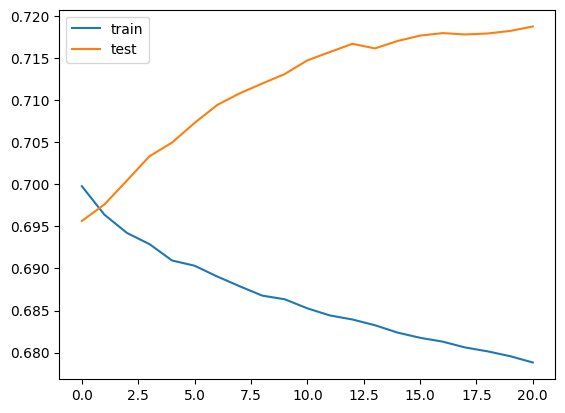

In [25]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


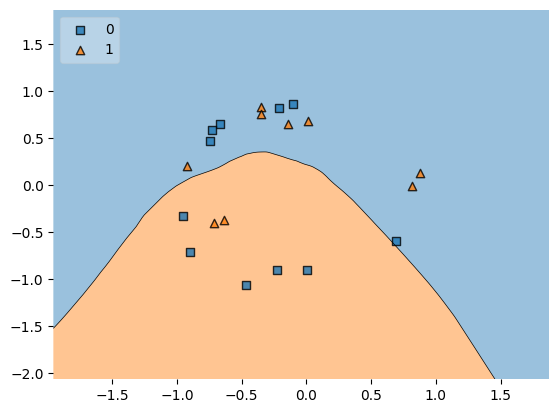

In [26]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()